# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [133]:
import numpy as np
import pandas as pd
import seaborn as sns

In [134]:
raw = pd.read_csv('/content/airbnb_hw.csv')
raw.rename(columns = {'Neighbourhood ': 'Neighbourhood'}, inplace = True)

In [135]:
raw.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='object')

In [136]:
raw.dtypes

,0
Host Id,int64
Host Since,object
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [137]:
raw['Price'].unique()

array(['145', '37', '28', '199', '549', '149', '250', '90', '270', '290',
       '170', '59', '49', '68', '285', '75', '100', '150', '700', '125',
       '175', '40', '89', '95', '99', '499', '120', '79', '110', '180',
       '143', '230', '350', '135', '85', '60', '70', '55', '44', '200',
       '165', '115', '74', '84', '129', '50', '185', '80', '190', '140',
       '45', '65', '225', '600', '109', '1,990', '73', '240', '72', '105',
       '155', '160', '42', '132', '117', '295', '280', '159', '107', '69',
       '239', '220', '399', '130', '375', '585', '275', '139', '260',
       '35', '133', '300', '289', '179', '98', '195', '29', '27', '39',
       '249', '192', '142', '169', '1,000', '131', '138', '113', '122',
       '329', '101', '475', '238', '272', '308', '126', '235', '315',
       '248', '128', '56', '207', '450', '215', '210', '385', '445',
       '136', '247', '118', '77', '76', '92', '198', '205', '299', '222',
       '245', '104', '153', '349', '114', '320', '292', '22

In [138]:
raw['Price'] = raw['Price'].str.replace(',', '').astype(int)

In [139]:
raw.describe()

,Host Id,Review Scores Rating (bin),Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
count,3.047800e+04,22155.000000,30344.000000,30393.000000,30478.0,30478.000000,30478.000000,22155.000000
mean,1.273171e+07,90.738659,10584.854831,1.530089,1.0,12.018735,163.589737,91.993230
std,1.190270e+07,9.059519,921.299397,1.015359,0.0,21.980703,197.785454,8.850373
min,5.000000e+02,20.000000,1003.000000,0.000000,1.0,0.000000,10.000000,20.000000
25%,2.701298e+06,85.000000,10017.000000,1.000000,1.0,0.000000,80.000000,89.000000
50%,8.551693e+06,90.000000,10065.000000,1.000000,1.0,3.000000,125.000000,94.000000
75%,2.120617e+07,100.000000,11216.000000,2.000000,1.0,13.000000,195.000000,100.000000
max,4.303307e+07,100.000000,99135.000000,16.000000,1.0,257.000000,10000.000000,100.000000


In [140]:
raw['Room Type'].unique()

array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object)

In [141]:
raw['Property Type'].unique()

array(['Apartment', 'House', 'Other', 'Bed & Breakfast', 'Loft',
       'Condominium', 'Townhouse', nan, 'Dorm', 'Boat', 'Cabin', 'Villa',
       'Bungalow', 'Camper/RV', 'Treehouse', 'Tent', 'Hut', 'Lighthouse',
       'Chalet', 'Castle'], dtype=object)

In [142]:
raw['Neighbourhood'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
      dtype=object)

<Axes: xlabel='Price', ylabel='Density'>

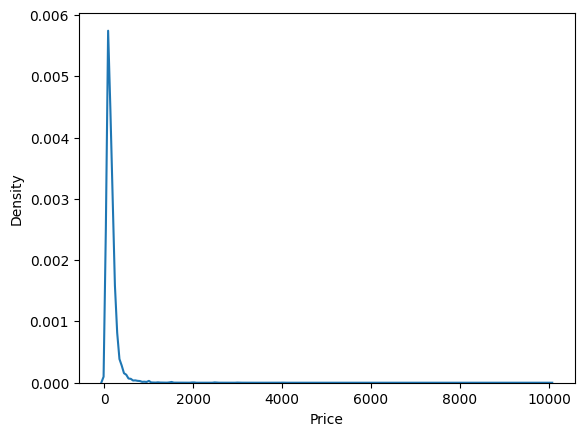

In [143]:
sns.kdeplot(raw['Price'])

In [144]:
raw['Host Since'] = pd.to_datetime(raw['Host Since'])

In [145]:
raw.dtypes

,0
Host Id,int64
Host Since,datetime64[ns]
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [146]:
raw = raw.dropna()
raw = raw.drop('Review Scores Rating (bin)', axis=1)

In [147]:
dummies = pd.get_dummies(raw[['Room Type', 'Property Type', 'Neighbourhood']], drop_first= True)
dummies

,Room Type_Private room,Room Type_Shared room,Property Type_Bed & Breakfast,Property Type_Boat,Property Type_Bungalow,Property Type_Cabin,Property Type_Camper/RV,Property Type_Castle,Property Type_Chalet,Property Type_Condominium,...,Property Type_Lighthouse,Property Type_Loft,Property Type_Other,Property Type_Townhouse,Property Type_Treehouse,Property Type_Villa,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30332,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
30347,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
30378,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
30404,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [148]:
df = raw.copy()
df = df.drop(['Room Type', 'Property Type', 'Neighbourhood', 'Host Id', 'Name', 'Zipcode'], axis = 1)
df = pd.concat([df, dummies], axis = 1)
df

,Host Since,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Room Type_Private room,Room Type_Shared room,Property Type_Bed & Breakfast,Property Type_Boat,...,Property Type_Lighthouse,Property Type_Loft,Property Type_Other,Property Type_Townhouse,Property Type_Treehouse,Property Type_Villa,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
4,2008-06-26,3.0,1,39,549,96.0,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,2008-07-25,1.0,1,4,149,100.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,2008-08-12,1.0,1,9,250,100.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,2008-08-15,1.0,1,80,90,94.0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
8,2008-08-20,2.0,1,95,270,90.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30332,2015-08-24,1.0,1,1,90,100.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
30347,2015-08-24,1.0,1,1,65,80.0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
30378,2015-08-25,1.0,1,1,55,100.0,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
30404,2015-08-27,1.0,1,1,60,100.0,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [154]:
X_train.columns

Index(['Beds', 'Number of Records', 'Number Of Reviews',
       'Review Scores Rating', 'Room Type_Private room',
       'Room Type_Shared room', 'Property Type_Bed & Breakfast',
       'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin',
       'Property Type_Camper/RV', 'Property Type_Castle',
       'Property Type_Chalet', 'Property Type_Condominium',
       'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut',
       'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other',
       'Property Type_Townhouse', 'Property Type_Treehouse',
       'Property Type_Villa', 'Neighbourhood_Brooklyn',
       'Neighbourhood_Manhattan', 'Neighbourhood_Queens',
       'Neighbourhood_Staten Island'],
      dtype='object')

In [150]:
from sklearn.model_selection import train_test_split
X = df.drop(['Price', 'Host Since'], axis = 1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#All variables
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
#Best model

R² Score: 0.30
RMSE: 116.15


In [157]:
#All Numeric
model1 = LinearRegression()
model1.fit(X_train[['Beds', 'Number of Records', 'Number Of Reviews',
       'Review Scores Rating']], y_train)
y_pred1 = model1.predict(X_test[['Beds', 'Number of Records', 'Number Of Reviews',
       'Review Scores Rating']])
print(f"R² Score: {r2_score(y_test, y_pred1):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1)):.2f}")

R² Score: 0.19
RMSE: 124.83
